The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


index,year,:,int64,(no nulls)
column,reports,:,int64,(no nulls)


<Axes: xlabel='year'>

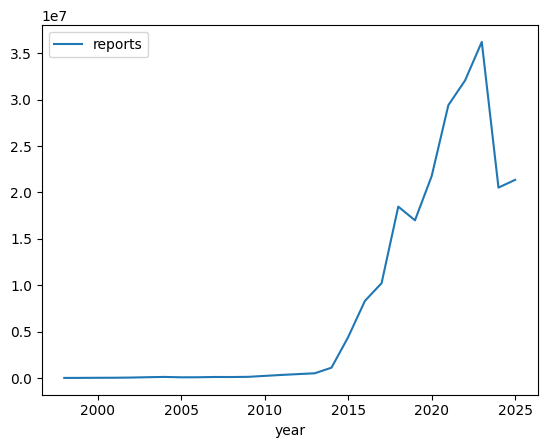

In [ ]:
import sys
sys.path.insert(0, '..')

import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.transforms as mtrans
import numpy as np
import pandas as pd
from diaphanous import show

%load_ext rpy2.ipython
import diaphanous.arr as arr
RLIB = arr.RLIB
arr.install()

reports = (
    pd.read_csv(
        '../data/ocse-reports-per-year.csv',
        thousands=',',
        index_col='year',
    ).sort_index(ascending=True)
)

show(reports, show_schema=True, caption='Reports')
reports.plot()

index,year,:,int64,(no nulls)
column,accounts,:,float64,(no nulls)


<Axes: xlabel='year'>

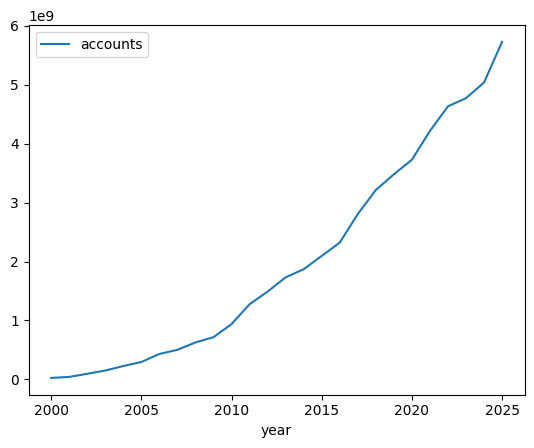

In [17]:

# Per DataReportal, there were 5.66 billion social media accounts in October
# 2025 and 5.79 billion social media accounts in April 2026. Approximate the
# count for January 2026.
accounts2025 = (5_660_000_000 + 5_790_000_000) / 2

accounts = (
    pd.read_csv('../data/social-accounts.csv')
    .assign(accounts=lambda df: df['million_accounts'] * 1_000_000)
    .drop(columns='million_accounts')
    .set_index('year')
)

assert accounts.loc[2025, 'accounts'] == accounts2025

show(accounts, show_schema=True, caption='Accounts')
accounts.plot()

In [24]:
data = (
    reports.join(accounts)
    .assign(
        reports_per_1k_accounts=lambda df: df['reports'] / (df['accounts'] / 1_000)
    )
    .reset_index()
)

data

,year,reports,accounts,reports_per_1k_accounts
0,1998,4560,NaN,NaN
1,1999,9668,NaN,NaN
2,2000,19245,2.500000e+07,0.769800
3,2001,24442,4.200000e+07,0.581952
4,2002,43078,9.500000e+07,0.453453
5,2003,81987,1.500000e+08,0.546580
6,2004,112017,2.268000e+08,0.493902
7,2005,70768,2.950000e+08,0.239892
8,2006,76584,4.313000e+08,0.177565
9,2007,105261,5.015000e+08,0.209892


In [ ]:
%%R -i RLIB -i data

.libPaths(RLIB)
library(tidyverse)
hr1 <- function() {
    print(strrep("-", 100))
}
hr2 <- function() {
    print(strrep("=", 100))
}

focus <- data |> filter(year >= 2014 & year < 2024)

focus.lm <- lm(reports ~ year, data = focus)
print(summary(focus.lm))
hr2()

focus.lmlog <- lm(log(reports) ~ year, data = focus)
print(summary(focus.lmlog))
hr1()
focus.lmlog.a <- exp(coef(focus.lmlog)[1])
focus.lmlog.b <- coef(focus.lmlog)[2]
print(c(focus.lmlog.a, focus.lmlog.b))
hr2()

longitud <- data |> filter(year < 2024)
longitud.lmlog <- lm(log(reports) ~ year, data = longitudinal)
print(summary(longitud.lmlog))
hr1()
longitud.lmlog.a <- exp(coef(longitud.lmlog)[1])
longitud.lmlog.b <- coef(longitud.lmlog)[2]
print(c(longitud.lmlog.a, longitud.lmlog.b))
hr2()

print(longitud.lmlog)


# focus.nls <- nls(
#     reports ~ a * exp(b * year), data = focus, start = list(a = start.a, b = start.b)
# )
# print(summary(focus.nls))

# plot(
#     data$year, data$reports, col = "blue",
#     main = "Reports per Year Regression",
#     xlab = "Year", ylab = "Reports"
# )

# lines(
#     longitud.lmlog$year, exp(fitted(longitud.lmlog)), col = "#a00000", lwd = 2, lty = 2
# )

#abline(focus.lm, col = "#00a000", lwd = 2)
#plot(exp(fitted(longitud.lmlog)), col = "#a00000", lwd = 2, lty = 2)


#lines(fitted(focus.lmlog), col = "red")

#     abline(focus.lm), cex = 1.3, pch = 16,



Call:
lm(formula = reports ~ year, data = focus)

Residuals:
     Min       1Q   Median       3Q      Max 
-2865792 -1279076   342308   831642  2537505 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -7.911e+09  4.030e+08  -19.63 4.72e-08 ***
year         3.928e+06  1.997e+05   19.67 4.64e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1814000 on 8 degrees of freedom
Multiple R-squared:  0.9797,	Adjusted R-squared:  0.9772 
F-statistic: 387.1 on 1 and 8 DF,  p-value: 4.636e-08

[1] "===================================================================================================="

Call:
lm(formula = log(reports) ~ year, data = focus)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.96075 -0.14269  0.07824  0.24818  0.54989 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -641.82807  102.69611  -6.250 0.000246 ***
year           0.32607    0.05088   6